# Prompt Style Comparison

Compare the prompt-style onepass runs (`concise`, `aspects`, `plansolve`, `budget`)
against the baseline onepass run (`none`) for every model and benchmark.

Three figures are produced:
- `figures/05_prompt_style_accuracy.png` — pass@1 accuracy per prompt style
- `figures/05_prompt_style_overflow.png` — reasoning overflow rate per prompt style
- `figures/05_prompt_style_average.png` — both metrics macro-averaged over all benchmarks

Averages are macro averages: every benchmark counts equally, regardless of how many
tasks it holds (they range from 165 to 1140), so no single benchmark dominates.

Prompt styles are appended to every user prompt and are onepass-only; they test whether
prompt engineering alone can reduce reasoning length enough to avoid overflow.


In [1]:
"""Prompt style (concise / aspects / plansolve / budget) vs. baseline accuracy and overflow."""

import json
from collections.abc import Callable
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# --- configuration ---

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = Path("../output")

# max token budget used in all greedy runs
MAX_TOKENS = 32768

# colours match the SERIES dict in notebooks 02 and 03
SERIES: dict[str, dict] = {
    "qwen3_8b": {"label": "Qwen3-8B", "model_key": "qwen3-8b", "colour": "#377EB8"},
    "qwen3_14b": {"label": "Qwen3-14B", "model_key": "qwen3-14b", "colour": "#009688"},
    "qwen3_32b": {"label": "Qwen3-32B", "model_key": "qwen3-32b", "colour": "#00BCD4"},
    "olmo_3_7b": {"label": "OLMo3-7B", "model_key": "olmo-3-7b", "colour": "#FF7F00"},
    "llama_r1_8b": {
        "label": "Llama-R1-8B",
        "model_key": "llama-r1-8b",
        "colour": "#A65628",
    },
    "or_7b": {"label": "OpenReason-7B", "model_key": "or-7b", "colour": "#984EA3"},
    "ocr_7b": {"label": "CodeReason-7B", "model_key": "ocr-7b", "colour": "#F781BF"},
}

# benchmarks to plot: display name → key prefix used in the summary JSON keys.
# the full key is built as f"{prefix}_mx{MAX_TOKENS}_onepass{tag}", where tag is empty
# for the baseline and f"_{style}" for every other prompt style
DATASETS: dict[str, str] = {
    "EvalPlus": "code/evalplus_greedy",
    "BigCodeBench": "code/bigcodebench_greedy",
    "LiveCodeBench": "code/livecodebench_greedy",
    "CodeContests": "code/code_contests_greedy",
    "CRUX-Input": "crux/cruxeval_i_greedy",
    "CRUX-Output": "crux/cruxeval_o_greedy",
}

# prompt suffix keys (see _PROMPT_SUFFIXES in src/run_inference.py) → display label.
# the dict order sets the left-to-right bar order within each model group.
# the baseline label matches the "reasoning enabled" wording in notebooks 03 and 06
PROMPT_STYLES: dict[str, str] = {
    "none": "Reasoning enabled (default)",
    "concise": "Concise",
    "budget": "Token-Budget",
    "aspects": "Aspects",
    "plansolve": "Plan-and-Solve",
}

# baseline style key — every other style is compared against this one
BASELINE_STYLE = "none"

# font size constants — match notebooks 02 and 03
TITLE_SIZE = 13
FONT_SIZE = 11
TICK_SIZE = 10

In [3]:
def load_prompt_style_data() -> dict[str, dict[str, dict[str, dict]]]:
    """Load pass@1 and reasoning overflow rate for every model, benchmark and prompt style.

    Reads {model_key}_onepass.json from OUTPUT_DIR. All prompt styles live in the same
    per-model summary file; the baseline uses the plain _onepass key and other styles
    append their suffix key. Missing entries are recorded as None and reported.

    Returns a nested dict: series_key → dataset_label → style_key → {
        "pass": float | None, "pass_ci": [float, float] | None, "overflow": float | None,
    }
    """
    results: dict[str, dict[str, dict[str, dict]]] = {}

    for series_key, series_info in SERIES.items():
        model_key = series_info["model_key"]
        results[series_key] = {ds_label: {} for ds_label in DATASETS}

        # all prompt styles share one per-model onepass summary file
        summary_path = OUTPUT_DIR / f"{model_key}_onepass.json"
        summary = json.load(open(summary_path)) if summary_path.exists() else {}

        for ds_label, prefix in DATASETS.items():
            for style_key in PROMPT_STYLES:
                # baseline runs have no tag, other prompt styles append their key
                tag = "" if style_key == BASELINE_STYLE else f"_{style_key}"
                entry = summary.get(f"{prefix}_mx{MAX_TOKENS}_onepass{tag}")

                if entry is None:
                    print(f"  [skip] {series_key} / {ds_label} / {style_key} not found")
                    results[series_key][ds_label][style_key] = {
                        "pass": None,
                        "pass_ci": None,
                        "overflow": None,
                    }
                    continue

                # reasoning overflow: samples that spent the whole budget without answering
                results[series_key][ds_label][style_key] = {
                    "pass": entry["pass_at_1"],
                    "pass_ci": entry.get("pass_at_1_ci"),
                    "overflow": entry["statistics"]["reasoning_overflow_rate"],
                }

    return results


all_data = load_prompt_style_data()
print("loaded prompt style data for", len(all_data), "models")

loaded prompt style data for 7 models


In [4]:
def average_over_benchmarks(
    data: dict[str, dict[str, dict[str, dict]]],
) -> dict[str, dict[str, dict[str, float | None]]]:
    """Macro-average pass@1 and reasoning overflow rate over all benchmarks.

    Every benchmark counts equally, and benchmarks with a missing entry are left out
    of the average rather than counted as zero.

    Returns a nested dict: series_key → style_key → {"pass": float|None, "overflow": float|None}
    """
    averages: dict[str, dict[str, dict[str, float | None]]] = {}

    for series_key in SERIES:
        averages[series_key] = {}

        for style_key in PROMPT_STYLES:
            entry: dict[str, float | None] = {}

            for metric in ("pass", "overflow"):
                values = [
                    data[series_key][ds_label][style_key][metric]
                    for ds_label in DATASETS
                    if data[series_key][ds_label][style_key][metric] is not None
                ]
                entry[metric] = sum(values) / len(values) if values else None

            averages[series_key][style_key] = entry

    return averages


avg_data = average_over_benchmarks(all_data)
print("averaged", len(DATASETS), "benchmarks per model and prompt style")

averaged 6 benchmarks per model and prompt style


In [5]:
# visual encoding per prompt style: the baseline is a solid bar, the others form two
# families — length-directive prompts (concise/budget: mirrored diagonal hatches) and
# reasoning-restructure prompts (aspects/plansolve: rotated cross hatches) — with a
# shared alpha per family and hatch orientation separating the pair members
_STYLE_FILL: dict[str, dict] = {
    "none": {"alpha": 0.90, "hatch": None},
    "concise": {"alpha": 0.70, "hatch": "///"},
    "budget": {"alpha": 0.70, "hatch": "\\\\\\"},
    "aspects": {"alpha": 0.45, "hatch": "xxx"},
    "plansolve": {"alpha": 0.45, "hatch": "+++"},
}

# dark grey used for hatch lines and the neutral legend swatches
_GREY = "#555555"


def _add_ci_errorbar(
    ax: plt.Axes,
    x: float,
    y: float,
    ci: list[float] | None,
) -> None:
    """Draw a 95% CI error bar centred on the top of a bar.

    Asymmetric bounds [lo, hi] are preserved. Does nothing when ci is None.
    """
    if ci is None:
        return
    lo, hi = ci
    # convert proportions to percentages and clip to zero to avoid negative lengths
    yerr_lo = max(0.0, y - lo) * 100
    yerr_hi = max(0.0, hi - y) * 100
    ax.errorbar(
        x,
        y * 100,
        yerr=[[yerr_lo], [yerr_hi]],
        fmt="none",
        color="black",
        capsize=2,
        linewidth=1.0,
        zorder=5,
    )


def _draw_style_bars(
    ax: plt.Axes,
    get_bar: Callable[[str, str], tuple[float | None, list[float] | None]],
    title: str,
    ylabel: str,
) -> None:
    """Draw one bar group per model on ax, with one bar per prompt style.

    get_bar(series_key, style_key) returns the (value, ci) pair for a single bar; a
    value of None leaves that bar out. Bar colour identifies the model and the
    alpha/hatch identifies the prompt style. Values are proportions, plotted as
    percentages.
    """
    series_keys = list(SERIES.keys())
    style_keys = list(PROMPT_STYLES.keys())

    # bar geometry: the styles of one model share an integer x position, 0.8 wide overall
    n_styles = len(style_keys)
    bar_width = 0.8 / n_styles
    group_positions = np.arange(len(series_keys))

    for model_idx, series_key in enumerate(series_keys):
        colour = SERIES[series_key]["colour"]

        for style_idx, style_key in enumerate(style_keys):
            value, ci = get_bar(series_key, style_key)
            if value is None:
                continue

            # offset each style bar so the group stays centred on its x position
            offset = (style_idx - (n_styles - 1) / 2) * bar_width
            x = group_positions[model_idx] + offset
            fill = _STYLE_FILL[style_key]

            ax.bar(
                x,
                value * 100,
                width=bar_width,
                color=colour,
                alpha=fill["alpha"],
                hatch=fill["hatch"],
                edgecolor=_GREY if fill["hatch"] else "none",
                linewidth=0.5,
                zorder=3,
            )
            _add_ci_errorbar(ax, x, value, ci)

    ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold")
    ax.set_xticks(group_positions)
    ax.set_xticklabels(
        [SERIES[sk]["label"] for sk in series_keys],
        rotation=20,
        ha="right",
        fontsize=TICK_SIZE,
    )
    ax.set_ylabel(ylabel, fontstyle="italic", fontsize=FONT_SIZE)
    ax.tick_params(axis="y", labelsize=TICK_SIZE)
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.5, linewidth=1.2)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def _add_style_legend(fig: plt.Figure, y: float = 0.0) -> None:
    """Add a shared prompt style legend below the subplots.

    One neutral swatch per style, drawn with the same alpha and hatch as its bars.
    """
    style_keys = list(PROMPT_STYLES.keys())
    legend_handles = [
        mpatches.Patch(
            facecolor=_GREY if _STYLE_FILL[sk]["hatch"] is None else "#DDDDDD",
            alpha=_STYLE_FILL[sk]["alpha"],
            hatch=_STYLE_FILL[sk]["hatch"],
            edgecolor=_GREY,
            label=PROMPT_STYLES[sk],
        )
        for sk in style_keys
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(style_keys),
        fontsize=FONT_SIZE,
        frameon=False,
        bbox_to_anchor=(0.5, y),
    )


def plot_style_bars(
    data: dict[str, dict[str, dict[str, dict]]],
    metric: str,
    ylabel: str,
    save_path: Path,
    ci_metric: str | None = None,
    n_cols: int = 2,
) -> None:
    """Plot grouped bar charts of one metric per prompt style, for every benchmark.

    One subplot per benchmark in a 2-column grid matching notebook 03, each holding one
    bar group per model and one bar per prompt style. Error bars show the 95% confidence
    interval when ci_metric is given.
    Saves the figure as a PNG at save_path.
    """
    dataset_labels = list(DATASETS.keys())
    n_rows = (len(dataset_labels) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(13, 3.5 * n_rows),
        squeeze=False,
    )
    flat_axes = axes.flatten()

    for ax, ds_label in zip(flat_axes, dataset_labels):

        def get_bar(
            series_key: str,
            style_key: str,
            ds_label: str = ds_label,
        ) -> tuple[float | None, list[float] | None]:
            entry = data.get(series_key, {}).get(ds_label, {}).get(style_key, {})
            ci = entry.get(ci_metric) if ci_metric is not None else None
            return entry.get(metric), ci

        _draw_style_bars(ax=ax, get_bar=get_bar, title=ds_label, ylabel=ylabel)

    # hide spare axes when the dataset count is not divisible by n_cols
    for ax in flat_axes[len(dataset_labels) :]:
        ax.set_visible(False)

    _add_style_legend(fig)

    fig.tight_layout(rect=[0, 0.04, 1, 1], h_pad=2.5, w_pad=2)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"saved → {save_path}")
    plt.show()

saved → ../figures/05_prompt_style_accuracy.png


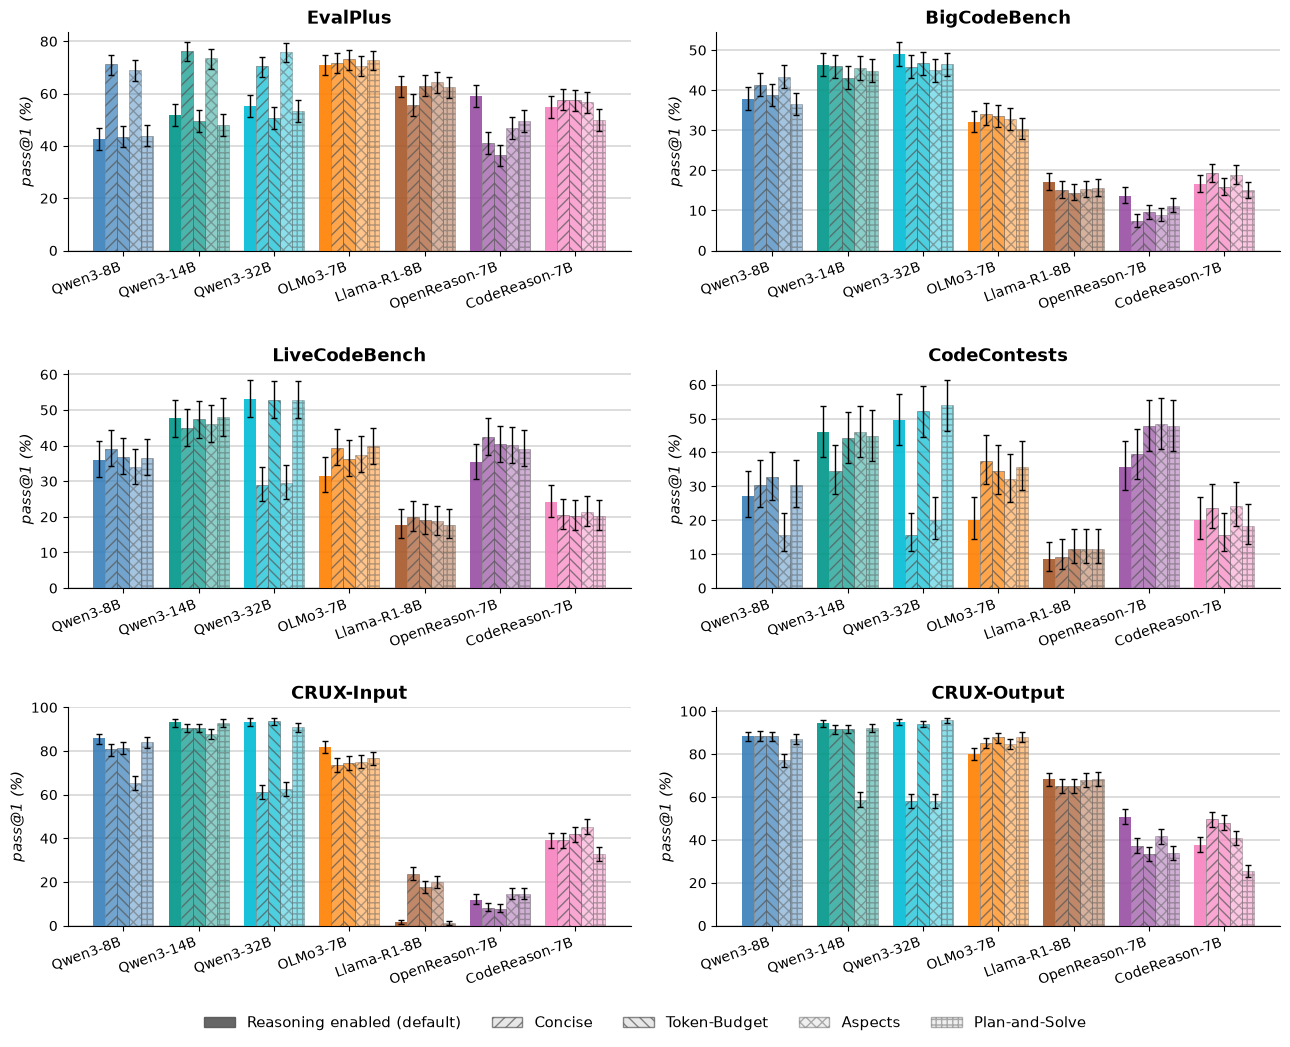

In [6]:
# --- pass@1 accuracy per prompt style ---
# bar colour = model, alpha/hatch = prompt style, error bars = 95% confidence interval

plot_style_bars(
    data=all_data,
    metric="pass",
    ci_metric="pass_ci",
    ylabel="pass@1 (%)",
    save_path=FIGURES_DIR / "05_prompt_style_accuracy.png",
)

saved → ../figures/05_prompt_style_overflow.png


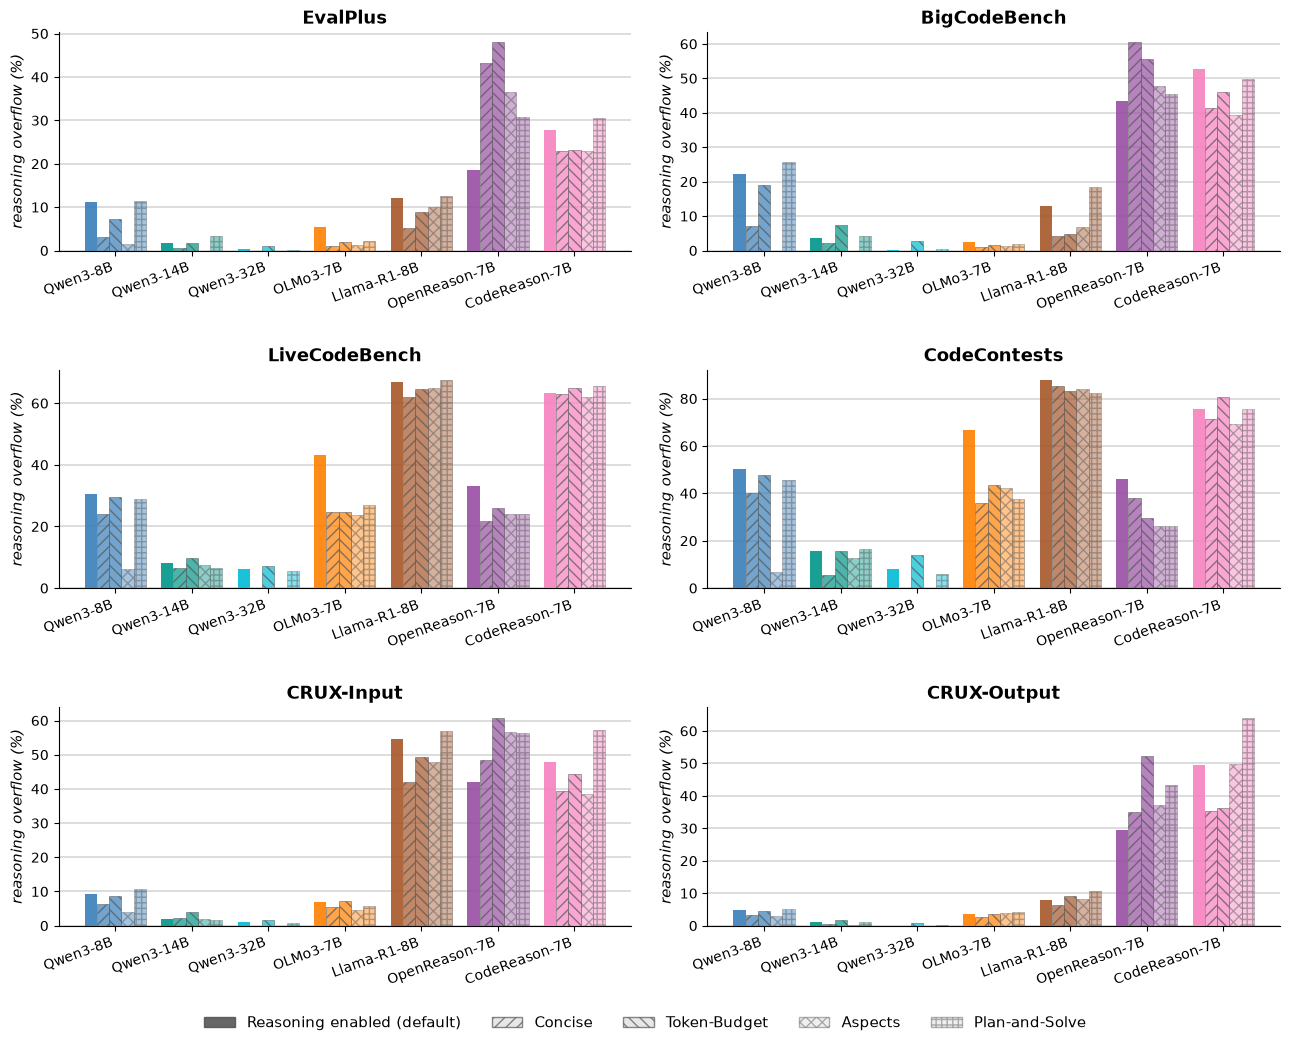

In [7]:
# --- reasoning overflow rate per prompt style ---
# overflow = the model spent the whole token budget reasoning and never gave an answer

plot_style_bars(
    data=all_data,
    metric="overflow",
    ylabel="reasoning overflow (%)",
    save_path=FIGURES_DIR / "05_prompt_style_overflow.png",
)

saved → ../figures/05_prompt_style_average.png


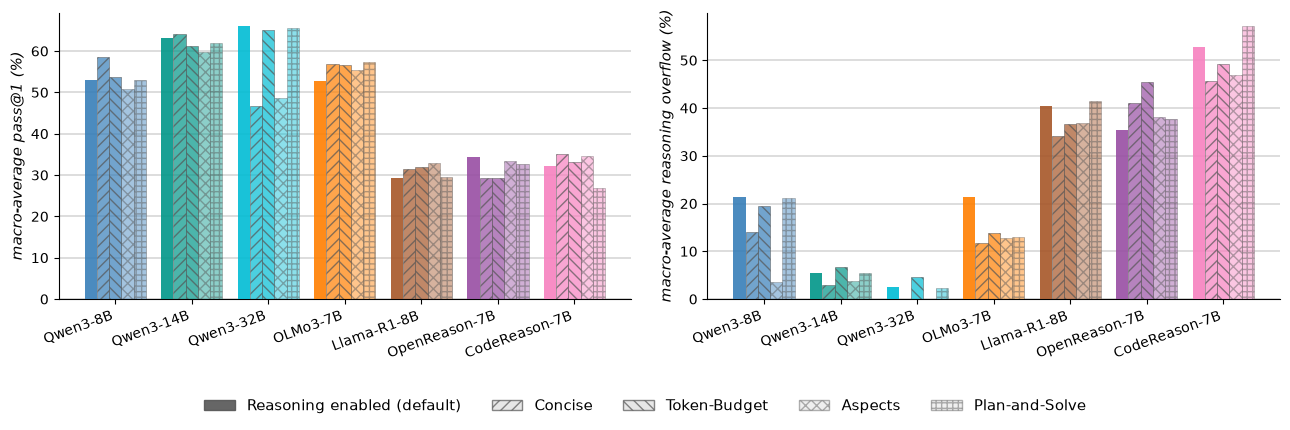

In [8]:
def plot_average_bars(
    averages: dict[str, dict[str, dict[str, float | None]]],
    save_path: Path,
) -> None:
    """Plot the macro-averaged pass@1 and overflow rate side by side.

    One panel per metric, each the same size as a subplot in the per-benchmark figures,
    so every model contributes ten points in total: five prompt styles × two metrics.
    No confidence intervals are drawn — the per-run intervals do not carry over to a
    mean across benchmarks.
    Saves the figure as a PNG at save_path.
    """
    # one panel per metric: (metric key, panel title, y-axis label)
    panels = [
        ("pass", "Macro-average pass@1", "macro-average pass@1 (%)"),
        (
            "overflow",
            "Macro-average reasoning overflow",
            "macro-average reasoning overflow (%)",
        ),
    ]

    # same width as the per-benchmark figures; the extra 0.3in over their 3.5in row
    # height offsets the legend so the axes themselves come out the same height
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(13, 4.3),
        squeeze=False,
    )

    for ax, (metric, title, ylabel) in zip(axes.flatten(), panels):

        def get_bar(
            series_key: str,
            style_key: str,
            metric: str = metric,
        ) -> tuple[float | None, list[float] | None]:
            return averages[series_key][style_key][metric], None

        _draw_style_bars(ax=ax, get_bar=get_bar, title=None, ylabel=ylabel)

    # the legend needs more headroom here because the figure is only one row tall
    _add_style_legend(fig, y=0)

    fig.tight_layout(rect=[0, 0.12, 1, 1], w_pad=2)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"saved → {save_path}")
    plt.show()


# --- both metrics, macro-averaged over all benchmarks ---
# left panel = macro-average pass@1, right panel = macro-average reasoning overflow

plot_average_bars(
    averages=avg_data,
    save_path=FIGURES_DIR / "05_prompt_style_average.png",
)

In [9]:
# --- summary table: macro average over benchmarks, with the change vs. baseline ---

# column widths derived from the longest model and style labels
COL_M = max(len(s["label"]) for s in SERIES.values()) + 2
COL_S = max(len(label) for label in PROMPT_STYLES.values()) + 2


def _delta(value: float | None, base: float | None) -> str:
    """Format the change against the baseline in percentage points.

    Returns a padded string, or blank for the baseline row and missing values.
    """
    if value is None or base is None:
        return ""
    return f"{100 * (value - base):+.1f}"


print(
    f"{'model':{COL_M}}  {'style':{COL_S}}  {'pass@1':>8}  {'Δ':>6}  {'overflow':>9}  {'Δ':>6}"
)
print(f"{'─' * COL_M}  {'─' * COL_S}  {'─' * 8}  {'─' * 6}  {'─' * 9}  {'─' * 6}")

for series_key, series_info in SERIES.items():
    # the same benchmark averages that the average figure plots
    means = avg_data[series_key]
    base = means[BASELINE_STYLE]

    for style_key, style_label in PROMPT_STYLES.items():
        row = means[style_key]
        model_cell = series_info["label"] if style_key == BASELINE_STYLE else ""
        pass_str = f"{100 * row['pass']:.1f}%" if row["pass"] is not None else "—"
        ovf_str = (
            f"{100 * row['overflow']:.1f}%" if row["overflow"] is not None else "—"
        )

        # the baseline row has nothing to compare against, so its deltas stay blank
        pass_d = (
            "" if style_key == BASELINE_STYLE else _delta(row["pass"], base["pass"])
        )
        ovf_d = (
            ""
            if style_key == BASELINE_STYLE
            else _delta(row["overflow"], base["overflow"])
        )

        print(
            f"{model_cell:{COL_M}}  {style_label:{COL_S}}  {pass_str:>8}  {pass_d:>6}  "
            f"{ovf_str:>9}  {ovf_d:>6}"
        )
    print()

model            style                            pass@1       Δ   overflow       Δ
───────────────  ─────────────────────────────  ────────  ──────  ─────────  ──────
Qwen3-8B         Reasoning enabled (default)       53.0%              21.4%        
                 Concise                           58.6%    +5.6      14.0%    -7.4
                 Token-Budget                      53.6%    +0.6      19.4%    -1.9
                 Aspects                           50.8%    -2.2       3.6%   -17.8
                 Plan-and-Solve                    53.1%    +0.1      21.2%    -0.1

Qwen3-14B        Reasoning enabled (default)       63.2%               5.4%        
                 Concise                           64.0%    +0.8       2.9%    -2.6
                 Token-Budget                      61.2%    -2.1       6.7%    +1.2
                 Aspects                           59.7%    -3.6       3.7%    -1.7
                 Plan-and-Solve                    61.8%    -1.4       5.5%